In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

In [ ]:
class LinearSVM:
    def __init__(self, regression=False, C=1.0, eps=0, learning_rate=0.001, max_iter=1000,
                 random_state=0):
        self.regression = regression
        self.C = C
        self.eps = eps
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        if self.regression:
            self.bias, self.weights = self._find_weights(X, y)
        else:
            classes = np.unique(y)
            n_classes = len(classes)
            _, n_features = X.shape

            self.bias = np.zeros(n_classes)
            self.weights = np.zeros((n_classes, n_features))
            np.random.seed(self.random_state)

            for i, cls in enumerate(classes):
                y_binary = np.where(y == cls, 1, -1)
                self.bias[i], self.weights[i] = self._find_weights(X, y_binary)

    def _find_weights(self, X, y):
        n_samples, n_features = X.shape
        bias = 0
        weights = np.zeros(n_features) if self.regression else np.random.randn(n_features)

        for _ in range(self.max_iter):
            for i in range(n_samples):
                y_pred = X[i] @ weights + bias
                margin = y[i] - y_pred if self.regression else y[i] * y_pred
                condition = np.abs(margin) > self.eps if self.regression else margin < 1

                   if condition:
                    if self.regression:
                        db = -self.C * (margin - self.eps)
                        dw = -self.C * (margin - self.eps) * X[i]
                    else:
                        db = -self.C * y[i]
                        dw = -self.C * y[i] * X[i]

                    bias -= self.learning_rate * db
                    weights -= self.learning_rate * dw

        return bias, weights

    def predict(self, X):
        scores = X @ self.weights.T + self.bias

        return scores if self.regression else np.argmax(scores, axis=1)

In [3]:
def decision_boundary_plot(X, y, X_train, y_train, clf, feature_indexes, title=None):
    feature1_name, feature2_name = X.columns[feature_indexes]
    X_feature_columns = X.values[:, feature_indexes]
    X_train_feature_columns = X_train[:, feature_indexes]
    clf.fit(X_train_feature_columns, y_train)

    plot_decision_regions(X=X_feature_columns, y=y.values, clf=clf)
    plt.xlabel(feature1_name)
    plt.ylabel(feature2_name)
    plt.title(title)

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

iris = load_iris()
iris = pd.DataFrame(data=np.c_[iris.data, iris.target], columns=iris.feature_names + ['target'])

X, y = iris.iloc[:, :-1], iris.iloc[:, -1]
y = pd.Series(LabelEncoder().fit_transform(y))
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, test_size=0.3, random_state=0)
print(iris)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  
0       0.0  

In [5]:
linear_svc = LinearSVM(random_state=0)
linear_svc.fit(X_train, y_train)
y_pred = linear_svc.predict(X_test)
from sklearn.metrics import accuracy_score
linear_svc_accuracy = accuracy_score(y_test, y_pred)

print(f'LinearSVC accuracy: {linear_svc_accuracy:}')
print(y_pred)

LinearSVC accuracy: 0.9333333333333333
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 2 0 0 2 0 0 1 1 0 2 2 0 2 2 1 0
 2 1 1 2 0 2 0 0]


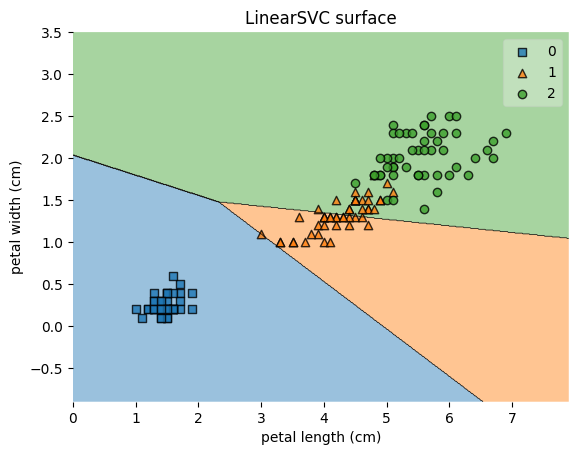

In [7]:
feature_indexes = [2, 3]
title1 = 'LinearSVC surface'
decision_boundary_plot(X, y, X_train, y_train, linear_svc, feature_indexes, title1)

In [9]:
linear_svr = LinearSVM(regression=True)
linear_svr.fit(X_train, y_train)
y_pred_svr = linear_svr.predict(X_test)
from sklearn.metrics import r2_score
linear_svr_r2 = r2_score(y_test, y_pred_svr)

print(f'LinearSVR r2 score: {linear_svr_r2:}')
print(y_pred_svr)

LinearSVR r2 score: 0.9087392240052922
[ 1.97755601  0.91041374 -0.17325261  1.78418652 -0.06678954  2.21193723
 -0.07350457  1.26063723  1.22260862  1.04879975  1.56364125  1.24956831
  1.20052454  1.26265453  1.30297176 -0.13120815  1.31179537  1.20708408
 -0.01365741 -0.08447176  1.74605401  1.3743125   0.08038256 -0.00247267
  1.52102494 -0.14913714  0.13621388  1.12022346  0.86368564  0.06457261
  1.69293234  1.40553481 -0.09793933  1.56576858  1.92645163  1.21142751
 -0.06661529  1.53676238  1.24051669  1.04430082  1.78397726 -0.07807602
  1.75486353  0.16701983 -0.1290166 ]
